Aligning dimensions: SHAP(24) vs Data(12)
Explaining: True Positive: Correctly Identified Fraud


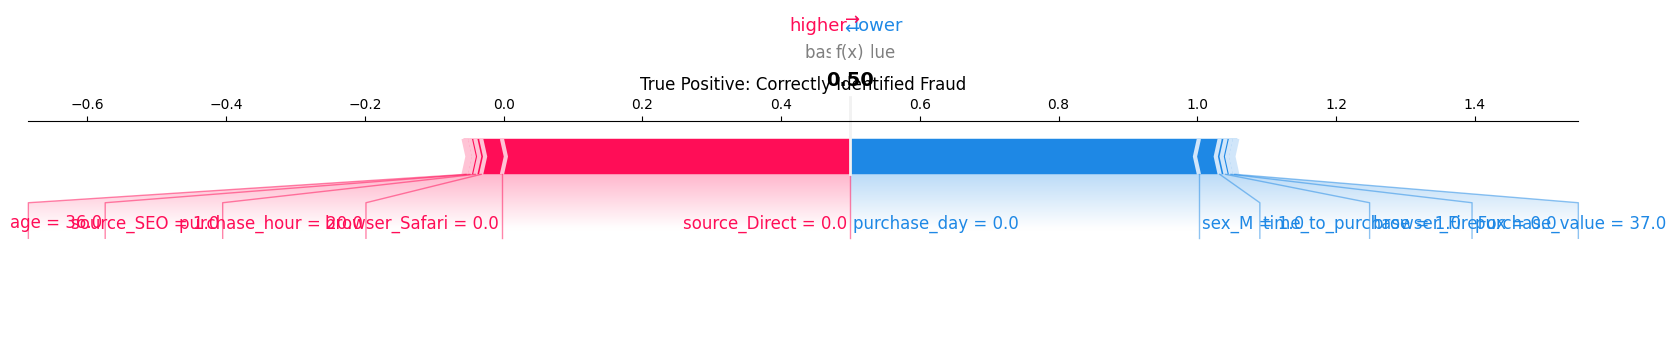

Aligning dimensions: SHAP(24) vs Data(12)
Explaining: False Positive: Legitimate Flagged as Fraud


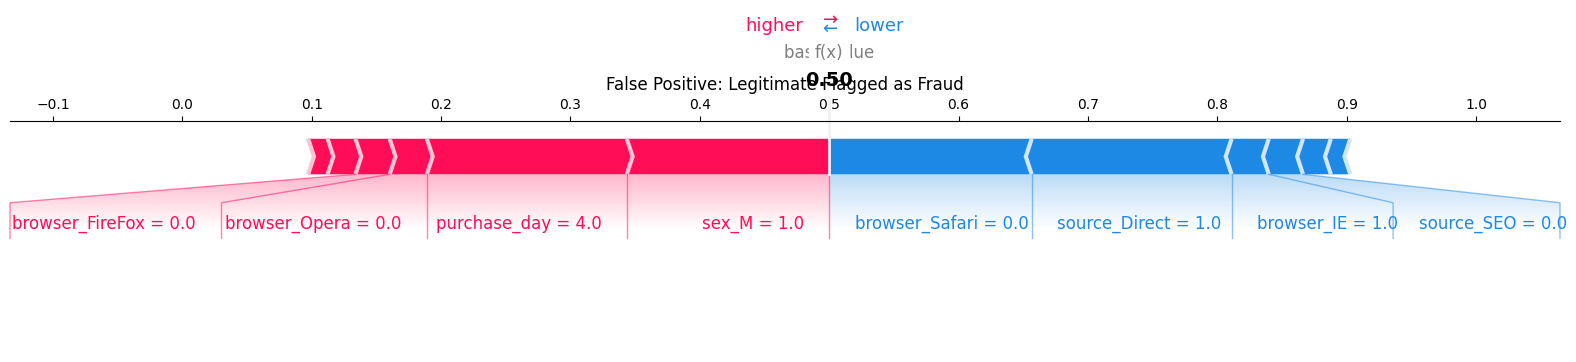

Aligning dimensions: SHAP(24) vs Data(12)
Explaining: False Negative: Missed Fraud Case


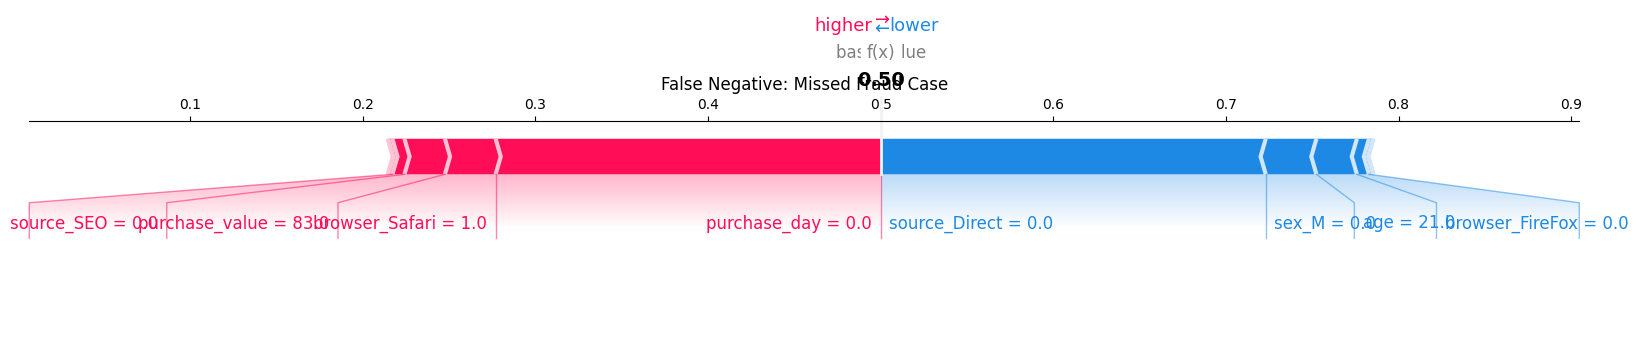

In [6]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# --- 1. LOAD ASSETS ---
model = joblib.load('../models/random_forest_fraud_model.pkl')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

# --- 2. SHAP INITIALIZATION ---
explainer = shap.TreeExplainer(model)
X_sample = X_test.iloc[:200]
shap_values = explainer.shap_values(X_sample)

# Handle binary classification: Extract values for Class 1 (Fraud)
if isinstance(shap_values, list):
    shap_obj = shap_values[1]
else:
    shap_obj = shap_values

# --- 3. THE FIXED PLOT FUNCTION ---
def plot_local_prediction(idx, title):
    # Ensure data is 1D
    instance_data = X_sample.iloc[idx].values.flatten()
    instance_shap = shap_obj[idx, :].flatten()
    feature_names = X_sample.columns.tolist()
    
    # Select the base value for Class 1 (Fraud)
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = explainer.expected_value[1]
    else:
        base_val = explainer.expected_value

    # --- THE FIX: Align dimensions if there is a mismatch ---
    if len(instance_shap) != len(instance_data):
        print(f"Aligning dimensions: SHAP({len(instance_shap)}) vs Data({len(instance_data)})")
        # If SHAP has one extra column (sometimes the base value), remove it
        if len(instance_shap) == len(instance_data) + 1:
            instance_shap = instance_shap[:-1]
        # Or if SHAP is shorter, truncate data (unlikely but safe)
        else:
            min_len = min(len(instance_shap), len(instance_data))
            instance_shap = instance_shap[:min_len]
            instance_data = instance_data[:min_len]
            feature_names = feature_names[:min_len]

    print(f"Explaining: {title}")
    
    # Generate the force plot
    shap.force_plot(
        base_val, 
        instance_shap, 
        instance_data, 
        feature_names=feature_names,
        matplotlib=True, 
        show=False
    )
    plt.title(title)
    plt.show()

# --- 4. EXECUTE PLOTS (Task 3.2) ---
y_pred = model.predict(X_sample)
y_actual = y_test.iloc[:200].values.flatten()

# 1. True Positive
tp_indices = np.where((y_actual == 1) & (y_pred == 1))[0]
if len(tp_indices) > 0:
    plot_local_prediction(tp_indices[0], "True Positive: Correctly Identified Fraud")

# 2. False Positive
fp_indices = np.where((y_actual == 0) & (y_pred == 1))[0]
if len(fp_indices) > 0:
    plot_local_prediction(fp_indices[0], "False Positive: Legitimate Flagged as Fraud")

# 3. False Negative
fn_indices = np.where((y_actual == 1) & (y_pred == 0))[0]
if len(fn_indices) > 0:
    plot_local_prediction(fn_indices[0], "False Negative: Missed Fraud Case")